In [34]:
df = pd.read_csv("train.csv")
df.dropna(inplace=True)
df["Type_of_vehicle"] = df["Type_of_vehicle"].str.strip()
df = df[
    (df["Restaurant_latitude"] != 0.0) &
    (df["Restaurant_longitude"] != 0.0) &
    (df["Delivery_location_latitude"] != 0.0) &
    (df["Delivery_location_longitude"] != 0.0) &
    (df["Type_of_vehicle"].isin(["motorcycle", "scooter"]))
]
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38425 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ID                           38425 non-null  object        
 1   Delivery_person_ID           38425 non-null  object        
 2   Delivery_person_Age          38425 non-null  object        
 3   Delivery_person_Ratings      38425 non-null  object        
 4   Restaurant_latitude          38425 non-null  float64       
 5   Restaurant_longitude         38425 non-null  float64       
 6   Delivery_location_latitude   38425 non-null  float64       
 7   Delivery_location_longitude  38425 non-null  float64       
 8   Order_Date                   38425 non-null  datetime64[ns]
 9   Time_Orderd                  38425 non-null  object        
 10  Time_Order_picked            38425 non-null  object        
 11  Weatherconditions            38425 non-null  o

C:\Users\upeks\AppData\Local\Temp\ipykernel_20812\149445266.py:11: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Order_Date"] = pd.to_datetime(df["Order_Date"])


In [35]:
df

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45587,0x1178,RANCHIRES16DEL01,35,4.2,23.371292,85.327872,23.481292,85.437872,2022-03-08,21:45:00,21:55:00,conditions Windy,Jam,2,Drinks,motorcycle,1,No,Metropolitian,(min) 33
45588,0x7c09,JAPRES04DEL01,30,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,11:35:00,11:45:00,conditions Windy,High,1,Meal,motorcycle,0,No,Metropolitian,(min) 32
45590,0x4f8d,CHENRES08DEL03,30,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,23:50:00,00:05:00,conditions Cloudy,Low,1,Drinks,scooter,0,No,Metropolitian,(min) 16
45591,0x5eee,COIMBRES11DEL01,20,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,13:35:00,13:40:00,conditions Cloudy,High,0,Snack,motorcycle,1,No,Metropolitian,(min) 26


In [36]:
temp_df = df[["Restaurant_latitude", "Restaurant_longitude"]]
temp_df = temp_df.groupby(by=["Restaurant_latitude", "Restaurant_longitude"]).size().reset_index(name="Count")
temp_df.sort_values(by=["Restaurant_latitude", "Restaurant_longitude"], inplace=True, ascending=False)
temp_df = temp_df[
    temp_df["Count"] > 150
]
temp_df.sort_values(by="Count", inplace=True, ascending=False)
temp_df = temp_df[
    (temp_df["Restaurant_latitude"] >= 26.0) &
    (temp_df["Restaurant_latitude"] <= 27.0) 
]

In [37]:
main_df = df[df["Restaurant_latitude"].isin(temp_df["Restaurant_latitude"])]

In [38]:
main_df = main_df[["Order_Date", "Delivery_location_latitude", "Delivery_location_longitude", "Time_Orderd", "Time_taken(min)"]]

In [39]:
scaler1 = StandardScaler()
main_df[["Latitude_Scaled", "Longitude_scaled"]] = scaler1.fit_transform(main_df[["Delivery_location_latitude", "Delivery_location_longitude"]])
main_df

,Order_Date,Delivery_location_latitude,Delivery_location_longitude,Time_Orderd,Time_taken(min),Latitude_Scaled,Longitude_scaled
25,2022-04-05,26.879596,75.830512,20:35:00,(min) 18,-1.488441,-0.798428
58,2022-03-26,26.898420,75.810689,09:25:00,(min) 20,-1.156295,-1.253571
84,2022-03-24,26.933483,75.823139,11:45:00,(min) 31,-0.537615,-0.967715
119,2022-04-03,26.922313,75.836896,20:50:00,(min) 25,-0.734708,-0.651850
173,2022-03-02,26.990262,75.863013,19:10:00,(min) 18,0.464239,-0.052195
...,...,...,...,...,...,...,...
45535,2022-03-09,26.876156,75.832300,23:50:00,(min) 17,-1.549139,-0.757375
45539,2022-03-19,26.952328,75.844257,20:50:00,(min) 28,-0.205099,-0.482839
45540,2022-03-03,26.933726,75.772820,08:30:00,(min) 25,-0.533328,-2.123055
45561,2022-03-15,26.906156,75.862300,19:35:00,(min) 31,-1.019795,-0.068565


In [40]:
def elbow_method(data, max_k):
    means = []
    inertias = []
    for k1 in range(1, max_k+1):
        kmeans_elbow = KMeans(n_clusters=k1)
        kmeans_elbow.fit(data)
        means.append(k1)
        inertias.append(kmeans_elbow.inertia_)
    
    plt.plot(means, inertias, "o-")
    plt.xlabel("K-Means")
    plt.ylabel("Inertias")
    plt.grid(True)
    plt.show()

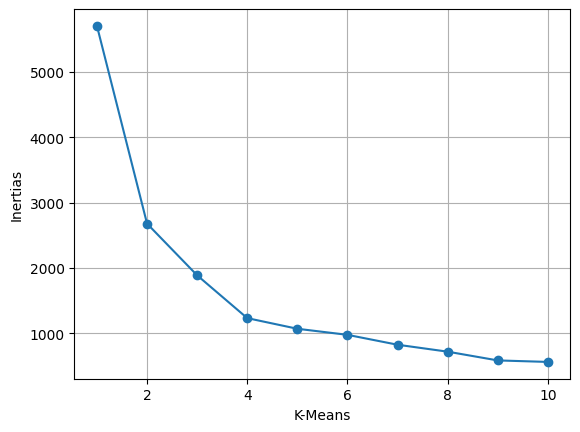

In [41]:
elbow_method(main_df[["Latitude_Scaled", "Longitude_scaled"]], 10)

In [42]:
kmeans_optmial = KMeans(n_clusters=4)
kmeans_optmial.fit(main_df[["Latitude_Scaled", "Longitude_scaled"]])
main_df["K-Means = 4"] = kmeans_optmial.labels_
main_df

,Order_Date,Delivery_location_latitude,Delivery_location_longitude,Time_Orderd,Time_taken(min),Latitude_Scaled,Longitude_scaled,K-Means = 4
25,2022-04-05,26.879596,75.830512,20:35:00,(min) 18,-1.488441,-0.798428,0
58,2022-03-26,26.898420,75.810689,09:25:00,(min) 20,-1.156295,-1.253571,0
84,2022-03-24,26.933483,75.823139,11:45:00,(min) 31,-0.537615,-0.967715,0
119,2022-04-03,26.922313,75.836896,20:50:00,(min) 25,-0.734708,-0.651850,0
173,2022-03-02,26.990262,75.863013,19:10:00,(min) 18,0.464239,-0.052195,2
...,...,...,...,...,...,...,...,...
45535,2022-03-09,26.876156,75.832300,23:50:00,(min) 17,-1.549139,-0.757375,0
45539,2022-03-19,26.952328,75.844257,20:50:00,(min) 28,-0.205099,-0.482839,0
45540,2022-03-03,26.933726,75.772820,08:30:00,(min) 25,-0.533328,-2.123055,0
45561,2022-03-15,26.906156,75.862300,19:35:00,(min) 31,-1.019795,-0.068565,0


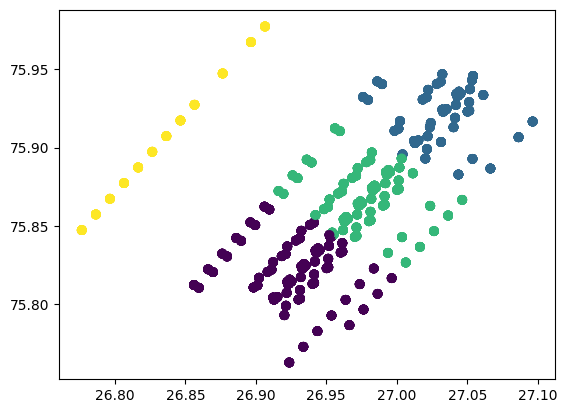

In [43]:
plt.scatter(x=main_df["Delivery_location_latitude"], y=main_df["Delivery_location_longitude"], c=main_df["K-Means = 4"])
plt.show()

In [73]:
cluster0_df = main_df[main_df["K-Means = 4"] == 0]
cluster0_VRP_df = main_df[main_df["K-Means = 4"] == 0]
cluster0_df = cluster0_df.groupby(by="Order_Date").size().reset_index(name="Number of Orders")
cluster0_df.sort_values(by="Order_Date", inplace=True)

In [ ]:
#cluster0_VRP_df = cluster0_VRP_df[(cluster0_VRP_df["Time_Orderd"] != 'NaN ') & (cluster0_VRP_df["Time_Orderd"] != '00:00:00')]
#cluster0_VRP_df

In [74]:
cluster0_VRP_df["Time_Orderd"] = pd.to_datetime(cluster0_VRP_df["Time_Orderd"], format="%H:%M:%S", errors="coerce").dt.time
cluster0_VRP_df["Time_taken(min)"] = cluster0_VRP_df["Time_taken(min)"].str.replace(r"\(min\)", "", regex=True).str.strip().astype(int)
cluster0_VRP_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1065 entries, 25 to 45588
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Order_Date                   1065 non-null   datetime64[ns]
 1   Delivery_location_latitude   1065 non-null   float64       
 2   Delivery_location_longitude  1065 non-null   float64       
 3   Time_Orderd                  1047 non-null   object        
 4   Time_taken(min)              1065 non-null   object        
 5   Latitude_Scaled              1065 non-null   float64       
 6   Longitude_scaled             1065 non-null   float64       
 7   K-Means = 4                  1065 non-null   int32         
dtypes: datetime64[ns](1), float64(4), int32(1), object(2)
memory usage: 70.7+ KB


C:\Users\upeks\AppData\Local\Temp\ipykernel_20812\3610214735.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster0_VRP_df["Time_Orderd"] = pd.to_datetime(cluster0_VRP_df["Time_Orderd"], format="%H:%M:%S", errors="coerce").dt.time


In [65]:
from datetime import time
start_time = time(12, 0)
end_time = time(16, 0)

In [70]:
cluster0_VRP_df = cluster0_VRP_df[cluster0_VRP_df["Time_Orderd"].apply(lambda x:start_time <= x <= end_time)]

TypeError: '<=' not supported between instances of 'datetime.time' and 'NaTType'

In [54]:
cluster0_VRP_df = cluster0_VRP_df.sample(n=50, random_state=42)
cluster0_VRP_df = cluster0_VRP_df[["Delivery_location_latitude", "Delivery_location_longitude", "Time_Orderd", "Time_taken(min)"]]

In [56]:
cluster0_VRP_df.reset_index(inplace=True)
cluster0_VRP_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   level_0                      50 non-null     int64  
 1   index                        50 non-null     int64  
 2   Delivery_location_latitude   50 non-null     float64
 3   Delivery_location_longitude  50 non-null     float64
 4   Time_Orderd                  50 non-null     object 
 5   Time_taken(min)              50 non-null     object 
dtypes: float64(2), int64(2), object(2)
memory usage: 2.5+ KB
